In [108]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

In [109]:
df=pd.read_csv('Used_Bikes.csv')

In [110]:
# Dataset Understanding
df

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha
...,...,...,...,...,...,...,...,...
32643,Hero Passion Pro 100cc,39000.0,Delhi,22000.0,First Owner,4.0,100.0,Hero
32644,TVS Apache RTR 180cc,30000.0,Karnal,6639.0,First Owner,9.0,180.0,TVS
32645,Bajaj Avenger Street 220,60000.0,Delhi,20373.0,First Owner,6.0,220.0,Bajaj
32646,Hero Super Splendor 125cc,15600.0,Jaipur,84186.0,First Owner,16.0,125.0,Hero


In [111]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  object 
 1   price       32648 non-null  float64
 2   city        32648 non-null  object 
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  object 
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.0+ MB


In [112]:
df.describe()

,price,kms_driven,age,power
count,3.264800e+04,32648.000000,32648.000000,32648.000000
mean,6.829542e+04,26344.625184,8.048211,213.511302
std,9.071860e+04,22208.527695,4.031700,134.428868
min,4.400000e+03,1.000000,1.000000,100.000000
25%,2.500000e+04,12000.000000,5.000000,150.000000
50%,4.300000e+04,20373.000000,7.000000,150.000000
75%,8.000000e+04,35000.000000,10.000000,220.000000
max,1.900000e+06,750000.000000,63.000000,1800.000000


In [113]:
df.columns

Index(['bike_name', 'price', 'city', 'kms_driven', 'owner', 'age', 'power',
       'brand'],
      dtype='object')

In [114]:
df.shape

(32648, 8)

In [115]:
# 2.Data Cleaning 
df.drop(columns='bike_name',inplace=True)

In [116]:
df['city'].isna().sum()

np.int64(0)

In [117]:
counts=df['city'].value_counts()

In [118]:
rare_city=counts[counts<=5].index

In [119]:
df['city']=df['city'].replace(rare_city,'Other')

In [120]:
df['city'].value_counts()

city
Delhi               7318
Bangalore           2723
Mumbai              2591
Hyderabad           2160
Pune                1724
                    ... 
Kharar                 6
Dakshina Kannada       6
Moradabad              6
Ajmer                  6
Dharwar                6
Name: count, Length: 93, dtype: int64

In [121]:
df.isnull().sum()
df.isnull().mean()*100

price         0.0
city          0.0
kms_driven    0.0
owner         0.0
age           0.0
power         0.0
brand         0.0
dtype: float64

In [122]:
df.duplicated().sum()

np.int64(25329)

In [123]:
df[df.duplicated(keep=False)].head(20)

,price,city,kms_driven,owner,age,power,brand
12,78000.0,Bangalore,9900.0,First Owner,4.0,200.0,Bajaj
14,29900.0,Delhi,20000.0,First Owner,7.0,125.0,Bajaj
16,120000.0,Bangalore,23000.0,First Owner,3.0,200.0,Bajaj
17,48000.0,Mumbai,24725.0,First Owner,5.0,150.0,Suzuki
19,29900.0,Delhi,20000.0,First Owner,7.0,125.0,Bajaj
20,120000.0,Bangalore,23000.0,First Owner,3.0,200.0,Bajaj
21,48000.0,Mumbai,24725.0,First Owner,5.0,150.0,Suzuki
25,78000.0,Bangalore,9900.0,First Owner,4.0,200.0,Bajaj
89,71800.0,Mumbai,43500.0,First Owner,7.0,350.0,Royal Enfield
90,71800.0,Mumbai,43500.0,First Owner,7.0,350.0,Royal Enfield


In [124]:
df.drop_duplicates(inplace=True)

In [125]:
df['brand'].value_counts()

brand
Bajaj              2081
Royal Enfield      1344
Hero               1141
Honda               675
Yamaha              651
TVS                 481
KTM                 375
Suzuki              203
Harley-Davidson      91
Kawasaki             61
Hyosung              52
Mahindra             50
Benelli              46
Triumph              21
Ducati               20
BMW                  10
Jawa                  7
Indian                3
MV                    3
Rajdoot               1
LML                   1
Yezdi                 1
Ideal                 1
Name: count, dtype: int64

In [126]:
# 3. no missing values 

In [127]:
#4. target value analysis 
df['price'].value_counts()

price
35000.0     183
25000.0     179
30000.0     154
45000.0     136
20000.0     134
           ... 
511000.0      1
146006.0      1
36995.0       1
72100.0       1
530000.0      1
Name: count, Length: 1232, dtype: int64

<Axes: xlabel='price', ylabel='Count'>

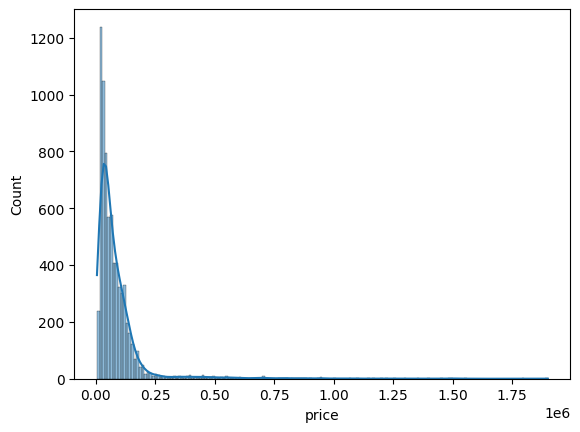

In [128]:
sns.histplot(df['price'],kde=True)

In [129]:
df.columns

Index(['price', 'city', 'kms_driven', 'owner', 'age', 'power', 'brand'], dtype='object')

<Axes: ylabel='price'>

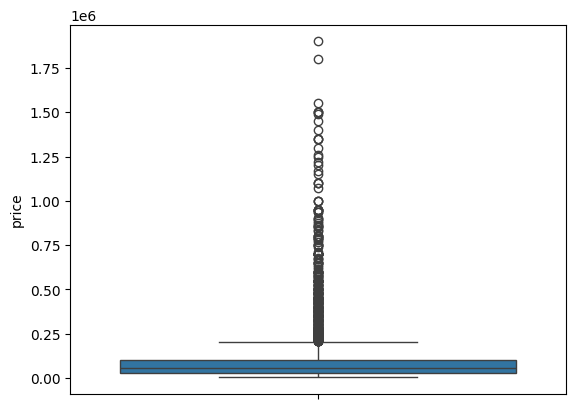

In [130]:

sns.boxplot(df['price'])

<Axes: xlabel='age', ylabel='Count'>

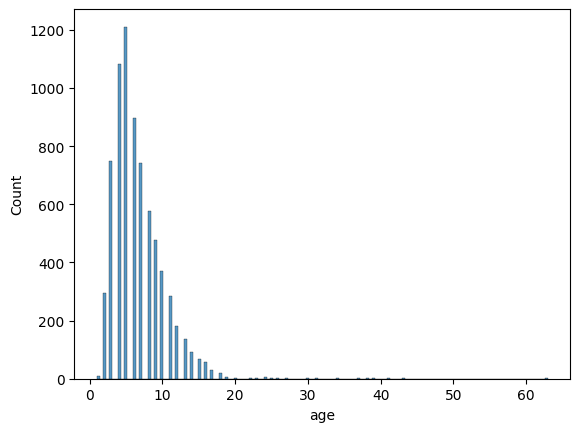

In [131]:
# 5. univariate analysis 
sns.histplot(df['age']) # mostly the bike sold are near 6,7 years

In [132]:
df['age'].mean()

np.float64(6.657603497745594)

<Axes: xlabel='age', ylabel='price'>

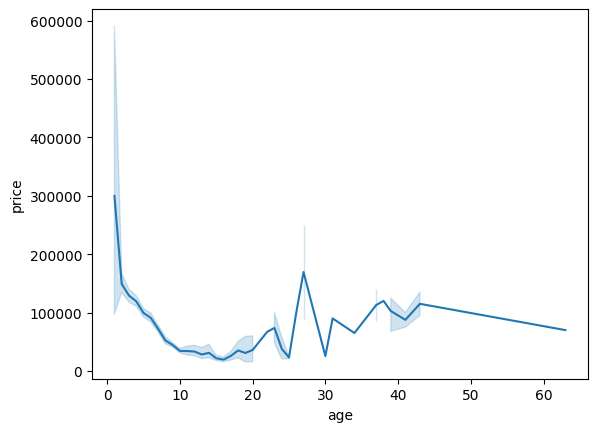

In [133]:
# bivariate analysis 
sns.lineplot(x=df['age'],y=df['price'])

<Axes: xlabel='brand', ylabel='price'>

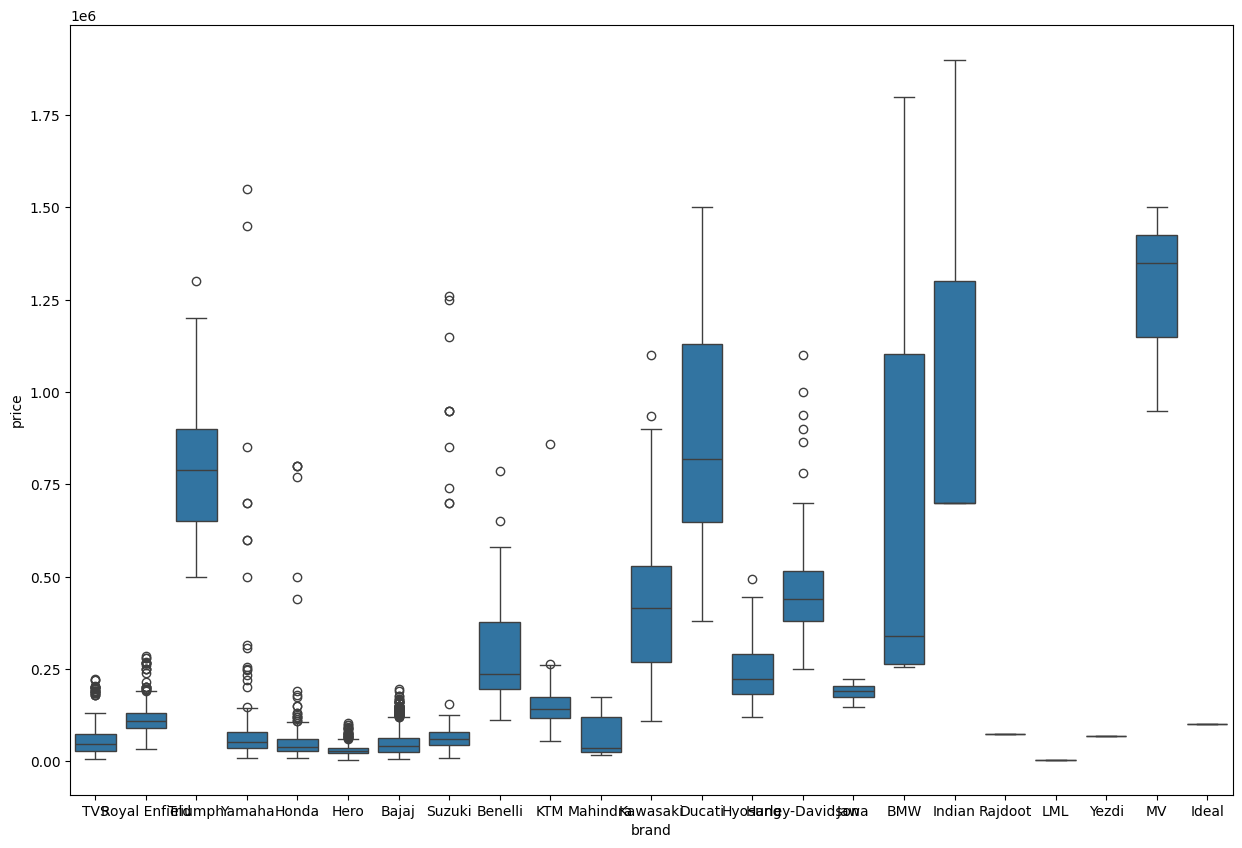

In [134]:
plt.figure(figsize=(15,10))
sns.boxplot(x=df['brand'],y=df['price'])

<Axes: >

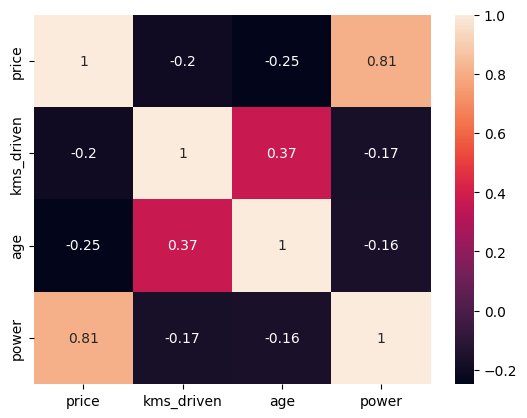

In [135]:
# multivariate analysis 
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [136]:
# there is power and price corrrelation little but it is okay since price depeneds somewhat on power ratio 

In [137]:
# Train test split 
X=df.drop(columns='price')
y=df['price']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [138]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth Owner Or More'], dtype=object)

In [139]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    transformers=[('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'),['brand','city']),
                  ('od',OrdinalEncoder(categories=[['First Owner', 'Second Owner', 'Third Owner','Fourth Owner Or More']]),['owner'])],
                  remainder='passthrough'
)

In [140]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

C:\Users\ayush\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [141]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error

In [142]:
def evalutaion(y_test,y_pred):
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = root_mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    return mae,mse,rmse,r2

In [143]:
models = {
    'Linear R': LinearRegression(),
    'Lasso R' : Lasso(),
    'Ridge R' : Ridge(),
    'KN Reg' : KNeighborsRegressor(),
    'DT R' : DecisionTreeRegressor(),
    'RF R' : RandomForestRegressor(),
    'Ada R': AdaBoostRegressor(),
    'Grad R': GradientBoostingRegressor(),
    'Grad R TUNED': GradientBoostingRegressor(n_estimators= 100,min_samples_split= 2,max_depth= 10,loss= 'huber',learning_rate= 0.1,criterion= 'squared_error'),
    'XG R' : XGBRegressor(),
    'XG R_ BEST' : XGBRegressor(n_estimators= 300,max_depth= 8,learning_rate= 0.1,colsample_bytree= 0.3),
    'SVR' : SVR()
}

In [144]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    print(f"TRAINING EVALUATION : {name}")
    mae,mse,rmse,r2=evalutaion(y_train,y_train_pred)
    print(f"mae : {mae}, mse : {mse}, rmse : {rmse}, r2 : {r2}")

    print(f"TESTING EVALUATION : {name}")
    mae,mse,rmse,r2=evalutaion(y_test,y_test_pred)
    print(f"mae : {mae}, mse : {mse}, rmse : {rmse}, r2 : {r2}")


TRAINING EVALUATION : Linear R
mae : 28578.14563232124, mse : 3271219161.943743, rmse : 57194.57283644789, r2 : 0.7816732899057585
TESTING EVALUATION : Linear R
mae : 28141.31831335194, mse : 3298281953.391535, rmse : 57430.67084225584, r2 : 0.761385608554643


C:\Users\ayush\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.385e+12, tolerance: 7.676e+09
  model = cd_fast.sparse_enet_coordinate_descent(


TRAINING EVALUATION : Lasso R
mae : 24666.907378529755, mse : 2482629350.0411654, rmse : 49825.99070807489, r2 : 0.8343051102525871
TESTING EVALUATION : Lasso R
mae : 24184.5019364771, mse : 2358479868.075512, rmse : 48564.18297547599, r2 : 0.829375642710507
TRAINING EVALUATION : Ridge R
mae : 38447.64613917004, mse : 4997948176.08198, rmse : 70696.16804383375, r2 : 0.6664284694831891
TESTING EVALUATION : Ridge R
mae : 37892.852882604464, mse : 5103589825.190354, rmse : 71439.41366773915, r2 : 0.6307805101160949
TRAINING EVALUATION : KN Reg
mae : 22913.55248877611, mse : 3358305012.361109, rmse : 57950.884482992224, r2 : 0.7758610326780632
TESTING EVALUATION : KN Reg
mae : 28226.376867030966, mse : 5044666578.794354, rmse : 71025.81628390028, r2 : 0.6350433156552966
TRAINING EVALUATION : DT R
mae : 204.0115166894398, mse : 19945325.053777084, rmse : 4466.0189267150545, r2 : 0.998668815207672
TESTING EVALUATION : DT R
mae : 17077.262067395262, mse : 3006676888.4404597, rmse : 54833.1732

In [145]:
#Xg  boost hyperparameter tuning 
params={
    "learning_rate": [0.1, 0.01],
    "max_depth": [5, 8, 12, 20, 30],
    "n_estimators": [100, 200, 300],
    "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]
}

In [146]:
from sklearn.model_selection import RandomizedSearchCV
rd=RandomizedSearchCV(estimator=XGBRegressor(),param_distributions=params,n_iter=50,cv=3,verbose=3,n_jobs=-1)

In [147]:
rd.fit(X_train,y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.5, 0.8, ...], 'learning_rate': [0.1, 0.01], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,50
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [148]:
rd.best_params_

{'n_estimators': 300,
 'max_depth': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 1}

In [158]:
bikes_to_check = pd.DataFrame([
    {
        "city": "Mumbai",
        "kms_driven": 38000.0,
        "owner": "Third Owner",     
        "age": 8.0,
        "power": 400.0,
        "brand": "Bajaj"            # Dominar is a Bajaj model
    }
]) ## similarly add for you rbike 

In [159]:
bikes_transformed = preprocessor.transform(bikes_to_check)


In [160]:
for name, model in models.items():
    pred = model.predict(bikes_transformed[0:1])[0]
    print(f"{name:25s} → ₹{pred:,.0f}")

Linear R                  → ₹205,726
Lasso R                   → ₹162,809
Ridge R                   → ₹187,034
KN Reg                    → ₹72,588
DT R                      → ₹75,000
RF R                      → ₹98,350
Ada R                     → ₹100,126
Grad R                    → ₹102,932
Grad R TUNED              → ₹93,658
XG R                      → ₹76,268
XG R_ BEST                → ₹78,371
SVR                       → ₹54,500
